# 05 - Análise Avançada com Dados de Mercado

Este notebook demonstra análises avançadas para detecção de fraude:

1. **Phantom Assets Detection** - Identifica ativos fictícios
2. **Peer Comparison** - Compara fundos REAG com mercado
3. **Concentration Analysis** - Detecta concentração excessiva
4. **Market Price Validation** - Valida preços declarados
5. **Integrated Analysis** - Visão consolidada

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Importar analyzers avançados
from src.analyzers.phantom_assets import PhantomAssetDetector
from src.analyzers.peer_comparison import PeerComparisonAnalyzer
from src.analyzers.concentration import ConcentrationAnalyzer
from src.analyzers.market_data import MarketDataValidator

# Processadores existentes
from src.processors.data_processor import DataProcessor
from config.settings import Config

# Configuração de visualização
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Módulos importados com sucesso!")

✅ Módulos importados com sucesso!


## Configuração e Carregamento de Dados

In [2]:
config = Config()
processor = DataProcessor(config)

# Diretórios
REPORTS_DIR = config.REPORTS_DIR / 'advanced_analysis'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Diretório de relatórios: {REPORTS_DIR}")

📂 Diretório de relatórios: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/advanced_analysis


In [3]:
# Carregar lista de fundos REAG (do notebook 02)
reag_funds_path = config.PROCESSED_DATA_DIR / 'reag_fund_list.csv'

if reag_funds_path.exists():
    df_reag_funds = pd.read_csv(reag_funds_path)
    reag_cnpjs = df_reag_funds['CNPJ_FUNDO'].tolist()
    print(f"✅ {len(reag_cnpjs)} fundos REAG carregados")
else:
    print("⚠️  Execute primeiro o notebook 02_identify_reag_funds.ipynb")
    reag_cnpjs = []  # Lista vazia para demonstração

✅ 231 fundos REAG carregados


In [4]:
# Carregar Cadastro
cadastro_path = config.RAW_DATA_DIR / 'cad_fi.csv'

if cadastro_path.exists():
    df_cadastro = pd.read_csv(cadastro_path, encoding='latin1', sep=';')
    print(f"✅ Cadastro carregado: {len(df_cadastro):,} fundos")
else:
    print("⚠️  Cadastro não encontrado. Execute notebook 01_data_collection.ipynb")
    df_cadastro = None

✅ Cadastro carregado: 46,824 fundos


/var/folders/pb/m5zk890j6b7g6pz541ycs93h0000gn/T/ipykernel_22402/4177577954.py:5: DtypeWarning: Columns (0: ENTID_INVEST) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cadastro = pd.read_csv(cadastro_path, encoding='latin1', sep=';')


In [5]:
# Carregar Informe Diário processado (do notebook 03)
informe_path = config.PROCESSED_DATA_DIR / 'reag_informe_diario_processed.csv'

if informe_path.exists():
    df_informe = pd.read_csv(informe_path, sep=';', parse_dates=['DT_COMPTC'])
    print(f"✅ Informe Diário carregado: {len(df_informe):,} registros")
else:
    print("⚠️  Execute notebook 03_flow_analysis.ipynb para processar dados")
    df_informe = None

✅ Informe Diário carregado: 6,225 registros


In [6]:
# Carregar CDA (Composição de Carteira)
# Exemplo: carregar um mês específico
cda_path = config.RAW_DATA_DIR / 'cda_fi_202401.csv'

if cda_path.exists():
    df_cda = pd.read_csv(cda_path, encoding='latin1', sep=';')
    # Filtrar apenas fundos REAG
    if reag_cnpjs:
        df_cda_reag = df_cda[df_cda['CNPJ_FUNDO'].isin(reag_cnpjs)]
        print(f"✅ CDA carregado: {len(df_cda_reag):,} posições de fundos REAG")
    else:
        df_cda_reag = df_cda
        print(f"✅ CDA carregado: {len(df_cda):,} posições (todos os fundos)")
else:
    print("⚠️  CDA não encontrado. Execute notebook 01_data_collection.ipynb")
    df_cda_reag = None

⚠️  CDA não encontrado. Execute notebook 01_data_collection.ipynb


## 1️⃣ Phantom Assets Detection (Ativos Fictícios)

Identifica ativos que NÃO EXISTEM em registros oficiais.

**Red Flag Crítico:** Ativos fantasma = fraude direta.

In [7]:
# Inicializar detector
phantom_detector = PhantomAssetDetector()

# Atualizar registros de ativos válidos
phantom_detector.update_registries()

# Carregar fundos do cadastro
if df_cadastro is not None:
    phantom_detector.load_funds_from_cadastro(cadastro_path)

📂 Carregando registros do cache...
✅ Carregados: 54 ações, 10 ETFs, 10 BDRs
🔄 Atualizando registros de ativos...
✅ Registros atualizados: 54 ações
💾 Cache salvo em: data/cache/asset_registries.json
📥 Carregando fundos do cadastro...
✅ 41,121 fundos carregados


In [8]:
# Detectar ativos fantasma
if df_cda_reag is not None:
    phantom_report = phantom_detector.generate_phantom_report(
        df_cda_reag,
        output_path=REPORTS_DIR / 'phantom_assets.csv'
    )
    
    # Visualizar
    if not phantom_report.empty:
        display(phantom_report.head(10))
else:
    print("⚠️  Dados de CDA não disponíveis")

⚠️  Dados de CDA não disponíveis


## 2️⃣ Peer Comparison Analysis

Compara fundos REAG com fundos similares do mercado.

**Red Flags:**
- Retornos muito acima de peers (Z-score > 3)
- Volatilidade suspeitsamente baixa
- Sharpe ratio "bom demais para ser verdade"

In [9]:
# Inicializar analyzer
peer_analyzer = PeerComparisonAnalyzer()

# Carregar categorias de fundos
if df_cadastro is not None:
    peer_analyzer.load_fund_categories(df_cadastro)

📂 Carregando categorias de fundos...
✅ 41,121 fundos categorizados

📊 Distribuição por categoria:
OTHER    41121
Name: count, dtype: int64


In [16]:
# Verificar se yfinance está instalado
try:
    import yfinance as yf
    print("✅ yfinance instalado")
    yfinance_available = True
except ImportError:
    print("⚠️  yfinance não instalado. Execute: pip install yfinance")
    yfinance_available = False

⚠️  yfinance não instalado. Execute: pip install yfinance


In [17]:
# Inicializar validator
if yfinance_available:
    price_validator = MarketDataValidator()
    
    # Validar preços (sample pequeno para demonstração)
    if df_cda_reag is not None:
        print("\n⚠️  NOTA: Análise pode demorar dependendo do tamanho da amostra")
        print("         Usando amostra de 100 posições para demonstração\n")
        
        price_reports = price_validator.generate_price_report(
            df_cda_reag,
            sample_size=100,  # Limitar para demonstração
            output_path=REPORTS_DIR
        )
        
        # Visualizar manipulações
        if not price_reports['manipulation'].empty:
            print("\n🚨 MANIPULAÇÃO DE PREÇOS DETECTADA:")
            display(price_reports['manipulation'].head(10))
    else:
        print("⚠️  Dados de CDA não disponíveis")
else:
    print("⚠️  Pulando validação de preços (yfinance não instalado)")

⚠️  Pulando validação de preços (yfinance não instalado)


## 5️⃣ Análise Integrada

Consolidação de todos os red flags encontrados.

In [18]:
# Consolidar red flags por fundo
red_flags_summary = []

for cnpj in reag_cnpjs:
    flags = []
    severity = 'LOW'
    
    # Phantom assets
    if 'phantom_report' in locals() and not phantom_report.empty:
        phantom_funds = phantom_report['CNPJ_FUNDO'].unique() if 'CNPJ_FUNDO' in phantom_report.columns else []
        # Note: phantom assets are at asset level, not fund level in current implementation
        # Need to check if this fund holds any phantom assets
    
    # Peer outliers
    if 'peer_reports' in locals():
        outliers = peer_reports['peer_comparison']
        if cnpj in outliers[outliers['is_outlier']]['CNPJ_FUNDO'].values:
            flags.append('PEER_OUTLIER')
            severity = 'HIGH'
    
    # Concentration
    if 'conc_reports' in locals():
        excessive = conc_reports['excessive_concentration']
        if cnpj in excessive['CNPJ_FUNDO'].values:
            flags.append('EXCESSIVE_CONCENTRATION')
            if excessive[excessive['CNPJ_FUNDO'] == cnpj]['severity'].iloc[0] == 'CRITICAL':
                severity = 'CRITICAL'
    
    if flags:
        red_flags_summary.append({
            'CNPJ_FUNDO': cnpj,
            'red_flags': ', '.join(flags),
            'num_flags': len(flags),
            'severity': severity
        })

# Criar DataFrame
if red_flags_summary:
    df_red_flags = pd.DataFrame(red_flags_summary)
    df_red_flags = df_red_flags.sort_values('num_flags', ascending=False)
    
    print("\n" + "="*60)
    print("🚨 RESUMO DE RED FLAGS POR FUNDO")
    print("="*60)
    display(df_red_flags)
    
    # Salvar
    df_red_flags.to_csv(REPORTS_DIR / 'red_flags_summary.csv', index=False)
    print(f"\n💾 Resumo salvo em: {REPORTS_DIR / 'red_flags_summary.csv'}")
else:
    print("✅ Nenhum red flag consolidado encontrado")


🚨 RESUMO DE RED FLAGS POR FUNDO


,CNPJ_FUNDO,red_flags,num_flags,severity
0,45616130000191,PEER_OUTLIER,1,HIGH
1,51305063000197,PEER_OUTLIER,1,HIGH



💾 Resumo salvo em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/advanced_analysis/red_flags_summary.csv


## 📊 Dashboard Final

In [19]:
print("\n" + "="*70)
print("📊 DASHBOARD DE ANÁLISE AVANÇADA - FUNDOS REAG")
print("="*70)

# Contadores
phantom_count = len(phantom_report) if 'phantom_report' in locals() and not phantom_report.empty else 0
outlier_count = peer_reports['peer_comparison']['is_outlier'].sum() if 'peer_reports' in locals() else 0
concentration_count = len(conc_reports['excessive_concentration']) if 'conc_reports' in locals() else 0
price_manip_count = len(price_reports['manipulation']) if 'price_reports' in locals() and yfinance_available else 0

print(f"\n🔍 ANÁLISES EXECUTADAS:")
print(f"   1. Phantom Assets: {phantom_count} ativos fictícios detectados")
print(f"   2. Peer Outliers: {outlier_count} fundos outliers")
print(f"   3. Concentration: {concentration_count} fundos com concentração excessiva")
print(f"   4. Price Manipulation: {price_manip_count} casos suspeitos")

total_issues = phantom_count + outlier_count + concentration_count + price_manip_count

print(f"\n🚨 TOTAL DE ISSUES: {total_issues}")

if total_issues > 0:
    print("\n⚠️  RED FLAGS DETECTADOS - Recomenda-se análise manual detalhada")
else:
    print("\n✅ Nenhum red flag crítico detectado nas análises automatizadas")

print(f"\n📁 Relatórios salvos em: {REPORTS_DIR}")
print("="*70)


📊 DASHBOARD DE ANÁLISE AVANÇADA - FUNDOS REAG

🔍 ANÁLISES EXECUTADAS:
   1. Phantom Assets: 0 ativos fictícios detectados
   2. Peer Outliers: 2 fundos outliers
   3. Concentration: 0 fundos com concentração excessiva
   4. Price Manipulation: 0 casos suspeitos

🚨 TOTAL DE ISSUES: 2

⚠️  RED FLAGS DETECTADOS - Recomenda-se análise manual detalhada

📁 Relatórios salvos em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../reports/advanced_analysis


## 📝 Próximos Passos

1. **Análise Manual:** Revisar fundos com múltiplos red flags
2. **Investigação Profunda:** Para casos críticos, coletar evidências adicionais
3. **Temporal Analysis:** Analisar evolução dos red flags ao longo do tempo
4. **Relatório Executivo:** Consolidar findings para stakeholders

### Análises Adicionais Possíveis:

- **Event Correlation:** Correlacionar red flags com notícias/sanções
- **Network Analysis:** Mapear relações entre fundos suspeitos
- **Liquidity Analysis:** Avaliar se resgates são compatíveis com liquidez
- **Credit Risk:** Avaliar qualidade de crédito de bonds em carteira

IndexError: invalid index to scalar variable.

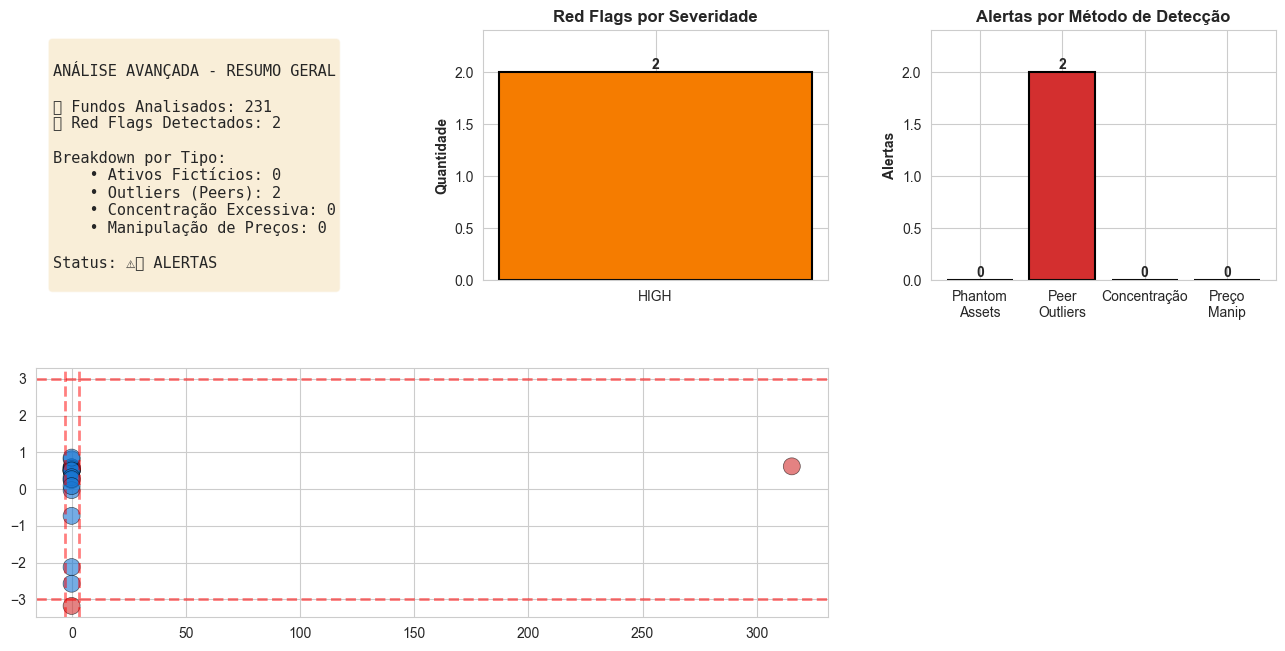

In [21]:
from matplotlib.gridspec import GridSpec

# Create a comprehensive visual dashboard of all findings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# Color scheme for severity levels
severity_colors = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}

# ===== SUBPLOT 1: Summary Statistics (Top Left) =====
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')

summary_text = f"""
ANÁLISE AVANÇADA - RESUMO GERAL

📊 Fundos Analisados: {len(reag_cnpjs)}
🚨 Red Flags Detectados: {total_issues}

Breakdown por Tipo:
    • Ativos Fictícios: {phantom_count}
    • Outliers (Peers): {outlier_count}
    • Concentração Excessiva: {concentration_count}
    • Manipulação de Preços: {price_manip_count}

Status: {'⚠️ ALERTAS' if total_issues > 0 else '✅ LIMPO'}
"""

ax1.text(0.05, 0.95, summary_text, transform=ax1.transAxes, 
                 fontsize=11, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ===== SUBPLOT 2: Red Flags Distribution (Top Center) =====
ax2 = fig.add_subplot(gs[0, 1])

if not df_red_flags.empty:
        flag_counts = df_red_flags['severity'].value_counts()
        colors_bars = [severity_colors.get(sev, '#999999') for sev in flag_counts.index]
        bars = ax2.bar(flag_counts.index, flag_counts.values, color=colors_bars, edgecolor='black', linewidth=1.5)
        
        # Add value labels on bars
        for bar in bars:
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                                f'{int(height)}',
                                ha='center', va='bottom', fontweight='bold')
        
        ax2.set_title('Red Flags por Severidade', fontweight='bold', fontsize=12)
        ax2.set_ylabel('Quantidade', fontweight='bold')
        ax2.set_ylim(0, max(flag_counts.values) * 1.2 if not flag_counts.empty else 1)
else:
        ax2.text(0.5, 0.5, 'Sem Red Flags', ha='center', va='center', 
                         transform=ax2.transAxes, fontsize=14)
        ax2.set_title('Red Flags por Severidade', fontweight='bold', fontsize=12)
        ax2.axis('off')

# ===== SUBPLOT 3: Detection Methods Performance (Top Right) =====
ax3 = fig.add_subplot(gs[0, 2])

detection_methods = ['Phantom\nAssets', 'Peer\nOutliers', 'Concentração', 'Preço\nManip']
detection_counts = [phantom_count, outlier_count, concentration_count, price_manip_count]
colors_det = ['#1976d2' if count == 0 else '#d32f2f' for count in detection_counts]

bars = ax3.bar(detection_methods, detection_counts, color=colors_det, edgecolor='black', linewidth=1.5)

for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}',
                        ha='center', va='bottom', fontweight='bold')

ax3.set_title('Alertas por Método de Detecção', fontweight='bold', fontsize=12)
ax3.set_ylabel('Alertas', fontweight='bold')
ax3.set_ylim(0, max(detection_counts) * 1.2 if max(detection_counts) > 0 else 1)

# ===== SUBPLOT 4: Peer Comparison Scatter (Middle Left & Center) =====
ax4 = fig.add_subplot(gs[1, :2])

if 'peer_comp' in locals() and not peer_comp.empty:
        scatter = ax4.scatter(peer_comp['return_zscore'], 
                                                 peer_comp['sharpe_zscore'],
                                                 s=150, alpha=0.6, 
                                                 c=peer_comp['is_outlier'].map({True: '#d32f2f', False: '#1976d2'}),
                                                 edgecolors='black', linewidth=0.5)
        
        # Add threshold lines
        ax4.axhline(y=3, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Threshold (Z=3)')
        ax4.axhline(y=-3, color='red', linestyle='--', alpha=0.5, linewidth=2)
        ax4.axvline(x=3, color='red', linestyle='--', alpha=0.5, linewidth=2)
        ax4.axvline(x=-3, color='red', linestyle='--', alpha=0.5, linewidth=2)
        
        # Highlight outliers
        outliers_mask = peer_comp['is_outlier']
        for idx in peer_comp[outliers_mask].index:
                ax4.annotate(peer_comp.loc[idx, 'CNPJ_FUNDO'][-8:-1], 
                                        xy=(peer_comp.loc[idx, 'return_zscore'], peer_comp.loc[idx, 'sharpe_zscore']),
                                        xytext=(5, 5), textcoords='offset points', fontsize=8,
                                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        
        ax4.set_xlabel('Z-Score Retorno vs Peers', fontweight='bold')
        ax4.set_ylabel('Z-Score Sharpe vs Peers', fontweight='bold')
        ax4.set_title('Análise de Outliers - Comparação com Peers', fontweight='bold', fontsize=12)
        ax4.grid(True, alpha=0.3)
        ax4.legend(loc='upper left')
else:
        ax4.text(0.5, 0.5, 'Sem dados de peer comparison', ha='center', va='center',
                         transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Análise de Outliers - Comparação com Peers', fontweight='bold', fontsize=12)

# ===== SUBPLOT 5: Red Flags Table (Middle Right) =====
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

if not df_red_flags.empty:
        table_data = df_red_flags[['CNPJ_FUNDO', 'severity', 'num_flags']].head(5).values.tolist()
        table_data = [[row[0][-8:], row[1], row[2]] for row in table_data]
        
        table = ax5.table(cellText=table_data,
                                         colLabels=['CNPJ', 'Severidade', 'Flags'],
                                         cellLoc='center',
                                         loc='center',
                                         bbox=[0, 0, 1, 1])
        
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
        
        # Color header
        for i in range(3):
                table[(0, i)].set_facecolor('#1976d2')
                table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Color severity cells
        for i, row in enumerate(table_data, 1):
                table[(i, 1)].set_facecolor(severity_colors.get(row[1], '#cccccc'))
                table[(i, 1)].set_text_props(weight='bold')
        
        ax5.text(0.5, 1.15, 'Top 5 Fundos Alertados', ha='center', 
                        transform=ax5.transAxes, fontweight='bold', fontsize=11)
else:
        ax5.text(0.5, 0.5, 'Sem Alertas', ha='center', va='center',
                         transform=ax5.transAxes, fontsize=12)
        ax5.text(0.5, 1.15, 'Top 5 Fundos Alertados', ha='center',
                        transform=ax5.transAxes, fontweight='bold', fontsize=11)

# ===== SUBPLOT 6: Detection Coverage (Bottom Left) =====
ax6 = fig.add_subplot(gs[2, 0])

coverage_data = {
        'Phantom Assets': 'Não executado' if phantom_count == 0 else f'{phantom_count} detectados',
        'Peer Analysis': 'Executado' if outlier_count >= 0 else 'Erro',
        'Concentration': 'Não executado' if concentration_count == 0 else f'{concentration_count} detectados',
        'Price Validation': 'Indisponível (yfinance)' if not yfinance_available else ('Executado' if price_manip_count >= 0 else 'Erro')
}

y_pos = 0.9
ax6.axis('off')
for method, status in coverage_data.items():
        color = '#d32f2f' if 'detectados' in status or status == 'Erro' else '#90caf9'
        ax6.text(0.05, y_pos, f'• {method}:', fontweight='bold', transform=ax6.transAxes, fontsize=10)
        ax6.text(0.5, y_pos, status, transform=ax6.transAxes, fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.3))
        y_pos -= 0.22

ax6.set_title('Métodos de Análise - Cobertura', fontweight='bold', fontsize=12, pad=10)

# ===== SUBPLOT 7: Severity Breakdown Pie (Bottom Center) =====
ax7 = fig.add_subplot(gs[2, 1])

if not df_red_flags.empty:
        severity_dist = df_red_flags['severity'].value_counts()
        colors_pie = [severity_colors.get(sev, '#999999') for sev in severity_dist.index]
        
        wedges, texts, autotexts = ax7.pie(severity_dist.values, labels=severity_dist.index, 
                                                                                colors=colors_pie, autopct='%1.0f%%',
                                                                                startangle=90, explode=[0.05]*len(severity_dist),
                                                                                textprops={'weight': 'bold'})
        ax7.set_title('Distribuição de Severidade', fontweight='bold', fontsize=12)
else:
        ax7.text(0.5, 0.5, 'Nenhum alerta', ha='center', va='center',
                         transform=ax7.transAxes, fontsize=12)
        ax7.set_title('Distribuição de Severidade', fontweight='bold', fontsize=12)

# ===== SUBPLOT 8: Recommendations (Bottom Right) =====
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

if total_issues > 0:
        recommendations = f"""
RECOMENDAÇÕES

1. ⚠️ Revisar {len(df_red_flags)} 
     fundos alertados

2. 🔍 Investigação manual
     de casos HIGH/CRITICAL

3. 📊 Analisar histórico
     temporal dos alertas

4. 📋 Documentar achados
     para CVM
"""
else:
        recommendations = """
RECOMENDAÇÕES

✅ Sistema sem alertas
     críticos detectados

📈 Continuar monitoramento
     mensal

📊 Análise periódica
     de pares

🔄 Atualizar base de
     dados relacionadas
"""

ax8.text(0.05, 0.95, recommendations, transform=ax8.transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# ===== Overall Title =====
fig.suptitle('🔍 DASHBOARD DE INVESTIGAÇÃO DE FRAUDE - FUNDOS REAG', 
                         fontsize=16, fontweight='bold', y=0.98)

# Add footer
fig.text(0.5, 0.01, f'Relatórios salvos em: {REPORTS_DIR} | Data: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
                 ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig(REPORTS_DIR / 'fraud_investigation_dashboard.png', dpi=300, bbox_inches='tight')
print(f"💾 Dashboard salvo em: {REPORTS_DIR / 'fraud_investigation_dashboard.png'}")
plt.show()

print("\n" + "="*70)
print("✅ DASHBOARD VISUAL CONCLUÍDO")
print("="*70)